# Heart Disease Classification

Machine learning project for the classification of heart disease using clinical patient data.

**Authors:** Petar Kuruc, Klara Zagajski, Lucija Čorak

## Project Overview

The goal of this project is to investigate clinical patient data and develop machine learning models for binary classification of heart disease.

The project includes:

- exploratory data analysis (EDA)
- data cleaning and preprocessing
- handling missing values
- categorical feature encoding
- feature normalization
- correlation analysis and data visualization
- training and optimization of multiple machine learning models
- model evaluation using Accuracy, Precision, Recall and F1-score
- comparison of binary and multiclass classification approaches

## Dataset

The project uses the **UCI Heart Disease dataset**, containing clinical information for 920 patients.

The dataset contains demographic information, clinical measurements and diagnostic test results.

The main target variable is `num`:

- `0` — no heart disease
- `1–4` — presence of heart disease with different severity levels

For the main task, the target variable was transformed into a binary classification problem:

- `0` → no heart disease
- `1–4` → heart disease

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import imblearn

## 1. Data Loading and Initial Inspection

In [2]:
dataset = pd.read_csv("heart_disease_uci.csv")

dataset.head(10)
# https://pythonguides.com/get-first-n-rows-of-pandas-dataframe/

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## 2. Data Cleaning

### 2.1. Constant and Monotonic Features

In [4]:
konst_vrijednosti = []
for i in dataset.columns:
    br_drugacijih = dataset[i].nunique()
    if br_drugacijih == 1:
        konst_vrijednosti.append(i)
print(f"Constant columns are: {konst_vrijednosti}")
# https://www.geeksforgeeks.org/pandas-dataframe-remove-constant-columns/

mon_vrijednosti = []
for i in dataset.columns:
    if dataset[i].is_monotonic_decreasing or dataset[i].is_monotonic_increasing:
        mon_vrijednosti.append(i)
print(f"Monotonic columns are: {mon_vrijednosti}")

Constant columns are: []
Monotonic columns are: ['id', 'dataset']


In [5]:
dataset2 = dataset.drop(["id", "dataset"], axis=1)
dataset2.head(15)
# https://www.geeksforgeeks.org/how-to-drop-one-or-multiple-columns-in-pandas-dataframe/

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,56,Male,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,57,Female,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,63,Male,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


### 2.2. Missing Values

In [6]:
broj_redaka = dataset2.shape[0]
print(f"Total number of rows in the dataset is: {broj_redaka}")
dataset2.isnull().sum()

Total number of rows in the dataset is: 920


age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

As we can see, there are many missing values across different variables. It is necessary to apply various statistical methods to obtain a complete dataset, so this is the next step for each feature.

In [7]:
missing_bp = dataset2[dataset2['trestbps'].isna()]
print(missing_bp)

     age     sex               cp  trestbps   chol    fbs           restecg  \
393   48  Female  atypical angina       NaN  308.0  False  st-t abnormality   
599   35    Male     asymptomatic       NaN    0.0    NaN            normal   
714   69    Male     asymptomatic       NaN    0.0  False  st-t abnormality   
733   63    Male      non-anginal       NaN    0.0  False    lv hypertrophy   
743   74    Male      non-anginal       NaN    0.0  False            normal   
746   51    Male     asymptomatic       NaN    0.0   True  st-t abnormality   
749   55    Male      non-anginal       NaN  228.0  False  st-t abnormality   
750   54    Male     asymptomatic       NaN    0.0  False  st-t abnormality   
756   60    Male     asymptomatic       NaN  281.0  False  st-t abnormality   
758   58    Male     asymptomatic       NaN  203.0   True            normal   
762   61    Male     asymptomatic       NaN    0.0   True  st-t abnormality   
764   57    Male     asymptomatic       NaN  277.0  

We notice that some rows have more than one NaN value, so we will identify all rows with more than one missing value.

In [8]:
rows_with_multiple_nans = dataset2[dataset2.isna().sum(axis=1) > 1]
print("Rows with more than one NaN value:")
print(rows_with_multiple_nans)

print(f"\nNumber of rows with more than one NaN value: {len(rows_with_multiple_nans)}")
print(f"Total number of rows in the dataset: {len(dataset2)}")
print(f"Percentage of rows with more than one NaN value: {(len(rows_with_multiple_nans)) / (len(dataset2)) * 100:.2f}%")

Rows with more than one NaN value:
     age     sex               cp  trestbps   chol    fbs           restecg  \
303   28    Male  atypical angina     130.0  132.0  False    lv hypertrophy   
304   29    Male  atypical angina     120.0  243.0  False            normal   
305   29    Male  atypical angina     140.0    NaN  False            normal   
306   30  Female   typical angina     170.0  237.0  False  st-t abnormality   
307   31  Female  atypical angina     100.0  219.0  False  st-t abnormality   
..   ...     ...              ...       ...    ...    ...               ...   
915   54  Female     asymptomatic     127.0  333.0   True  st-t abnormality   
916   62    Male   typical angina       NaN  139.0  False  st-t abnormality   
917   55    Male     asymptomatic     122.0  223.0   True  st-t abnormality   
918   58    Male     asymptomatic       NaN  385.0   True    lv hypertrophy   
919   62    Male  atypical angina     120.0  254.0  False    lv hypertrophy   

     thalch  exa

60% of our data has more than one NaN value. This is an extremely large amount, and we are now facing the challenge of how to fill these gaps.

First, we will identify the rows with more than three NaN values, since these are already heavily incomplete records for a single example.

In [9]:
rows_with_more_than_3_nans = dataset2[dataset2.isna().sum(axis=1) > 3]
print("Rows with more than three NaN values:")
print(rows_with_more_than_3_nans)

print(f"\nNumber of rows with more than three NaN values: {len(rows_with_more_than_3_nans)}")
print(f"Total number of rows in the dataset: {len(dataset2)}")
print(f"Percentage of rows with more than three NaN values: {(len(rows_with_more_than_3_nans)) / (len(dataset2)) * 100:.2f}%")

Rows with more than three NaN values:
     age     sex               cp  trestbps   chol    fbs           restecg  \
305   29    Male  atypical angina     140.0    NaN  False            normal   
330   38  Female  atypical angina     120.0  275.0    NaN            normal   
337   39    Male  atypical angina     130.0    NaN  False            normal   
347   40    Male      non-anginal     140.0    NaN  False            normal   
375   45  Female  atypical angina     180.0    NaN  False            normal   
..   ...     ...              ...       ...    ...    ...               ...   
894   63    Male  atypical angina       NaN  165.0  False  st-t abnormality   
901   55    Male      non-anginal       NaN    NaN  False  st-t abnormality   
905   61    Male      non-anginal       NaN  284.0  False            normal   
916   62    Male   typical angina       NaN  139.0  False  st-t abnormality   
918   58    Male     asymptomatic       NaN  385.0   True    lv hypertrophy   

     thalch  

9% of the data with more than three NaN values appears to be a small enough proportion to remove without significantly reducing the dataset. Therefore, I will remove those rows.

In [10]:
dataset3 = dataset2[dataset2.isna().sum(axis=1) <= 3]

print(f"\nNumber of remaining rows after removal: {len(dataset3)}")
print(f"Percentage of rows with more than one NaN value: {(len(dataset3[dataset3.isna().sum(axis=1) > 1])) / (len(dataset3)) * 100:.2f}%")
dataset3.isnull().sum()


Number of remaining rows after removal: 834
Percentage of rows with more than one NaN value: 55.28%


age           0
sex           0
cp            0
trestbps      2
chol         10
fbs          80
restecg       0
thalch        0
exang         0
oldpeak       2
slope       225
ca          525
thal        405
num           0
dtype: int64

We can see that the variables with the most missing values are 'ca' and 'thal'. Since this is medical data with diagnostic test results that can significantly indicate heart disease, it would be better to impute the NaN values rather than remove them.

Since I do not plan to remove anything beyond NaN values and instead replace them, we will first convert all categorical variables to numerical form and then apply the kNN model to the dataset to impute missing values, following the companion research article.

### 2.3. Categorical Feature Encoding

In [11]:
numeric_variables = dataset3.select_dtypes(include=['number']).columns
print("Numeric variables:", numeric_variables.tolist())

categorical_variables = dataset3.select_dtypes(include=['object', 'category']).columns
print("Categorical variables:", categorical_variables.tolist())

Numeric variables: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Categorical variables: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [12]:
dataset4 = dataset3.copy()

sex_map = {"Male": 0, "Female": 1}
dataset4["sex"] = dataset4["sex"].map(sex_map)

cp_map = {"non-anginal": 0, "asymptomatic": 1, "typical angina": 2, "atypical angina": 3}
dataset4["cp"] = dataset4["cp"].map(cp_map)

if dataset4["fbs"].dropna().isin([True, False]).all():
    dataset4["fbs"] = dataset4["fbs"].map({True: 1, False: 0}).astype('Int64')
else:
    dataset4["fbs"] = pd.to_numeric(dataset4["fbs"], errors='coerce').astype('Int64')

restecg_map = {"normal": 0, "st-t abnormality": 1, "lv hypertrophy": 2}
dataset4["restecg"] = dataset4["restecg"].map(restecg_map)

dataset4["exang"] = dataset4["exang"].astype(int)

slope_map = {"upsloping": 0, "flat": 1, "downsloping": 2}
dataset4["slope"] = dataset4["slope"].map(slope_map)

thal_map = {"normal": 0, "reversable defect": 1, "fixed defect": 2}
dataset4["thal"] = dataset4["thal"].map(thal_map)

dataset4.head(400)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,0,2,145.0,233.0,1,2,150.0,0,2.3,2.0,0.0,2.0,0
1,67,0,1,160.0,286.0,0,2,108.0,1,1.5,1.0,3.0,0.0,2
2,67,0,1,120.0,229.0,0,2,129.0,1,2.6,1.0,2.0,1.0,1
3,37,0,0,130.0,250.0,0,0,187.0,0,3.5,2.0,0.0,0.0,0
4,41,1,3,130.0,204.0,0,2,172.0,0,1.4,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,49,1,0,130.0,207.0,0,1,135.0,0,0.0,NaN,NaN,NaN,0
408,49,0,3,100.0,253.0,0,0,174.0,0,0.0,NaN,NaN,NaN,0
409,49,0,0,140.0,187.0,0,0,172.0,0,0.0,NaN,NaN,NaN,0
410,49,0,1,120.0,297.0,<NA>,0,132.0,0,1.0,1.0,NaN,NaN,0


### 2.4. Feature Scaling and Missing Value Imputation

After converting the categorical variables to numerical representations, the remaining missing values were imputed using **K-Nearest Neighbors (KNN) imputation**.

Before applying KNN imputation, the numerical features were normalized using **Min-Max scaling**. This scales each feature to the range [0, 1], ensuring that features with larger numerical ranges do not disproportionately influence the distance calculations used by the KNN algorithm.

This preprocessing step is used to obtain a complete dataset for exploratory data analysis. The train-test split and model-specific preprocessing are performed separately in the classification sections.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

eda_data = dataset4.copy()

eda_scaler = MinMaxScaler()
eda_scaled = pd.DataFrame(eda_scaler.fit_transform(eda_data), columns=eda_data.columns, index=eda_data.index)

eda_imputer = KNNImputer(n_neighbors=5)
dataset5 = pd.DataFrame(eda_imputer.fit_transform(eda_scaled), columns=eda_data.columns, index=eda_data.index)

Let's check whether any NaN values remain and what the dataset looks like now.

In [14]:
print(dataset5.isna().sum())
dataset5.head(15)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0.714286,0.0,0.666667,0.725,0.386401,1.0,1.0,0.633803,0.0,0.556818,1.0,0.000000,1.0,0.00
1,0.795918,0.0,0.333333,0.800,0.474295,0.0,1.0,0.338028,1.0,0.465909,0.5,1.000000,0.0,0.50
2,0.795918,0.0,0.333333,0.600,0.379768,0.0,1.0,0.485915,1.0,0.590909,0.5,0.666667,0.5,0.25
3,0.183673,0.0,0.000000,0.650,0.414594,0.0,0.0,0.894366,0.0,0.693182,1.0,0.000000,0.0,0.00
4,0.265306,1.0,1.000000,0.650,0.338308,0.0,1.0,0.788732,0.0,0.454545,0.0,0.000000,0.0,0.00
5,0.571429,0.0,1.000000,0.600,0.391376,0.0,0.0,0.830986,0.0,0.386364,0.0,0.000000,0.0,0.00
6,0.693878,1.0,0.333333,0.700,0.444444,0.0,1.0,0.704225,0.0,0.704545,1.0,0.666667,0.0,0.75
7,0.591837,1.0,0.333333,0.600,0.587065,0.0,0.0,0.725352,1.0,0.363636,0.0,0.000000,0.0,0.00
8,0.714286,0.0,0.333333,0.650,0.421227,0.0,1.0,0.612676,0.0,0.454545,0.5,0.333333,0.5,0.50
9,0.510204,0.0,0.333333,0.700,0.336650,1.0,1.0,0.669014,1.0,0.647727,1.0,0.000000,0.5,0.25


Now that we have a complete and scaled dataset, we can move on to various analyses and graphical representations of the data.

## 3. Exploratory Data Analysis

We can first calculate and display the correlation matrix of the features in the dataset.

In [15]:
eda_data = dataset4.copy()

eda_scaler = MinMaxScaler()
eda_scaled = pd.DataFrame(eda_scaler.fit_transform(eda_data), columns=eda_data.columns, index=eda_data.index)

eda_imputer = KNNImputer(n_neighbors=5)
eda_imputed_scaled = pd.DataFrame(eda_imputer.fit_transform(eda_scaled), columns=eda_data.columns, index=eda_data.index)

eda_data = pd.DataFrame(eda_scaler.inverse_transform(eda_imputed_scaled), columns=eda_data.columns, index=eda_data.index)

### 3.1. Correlation Analysis

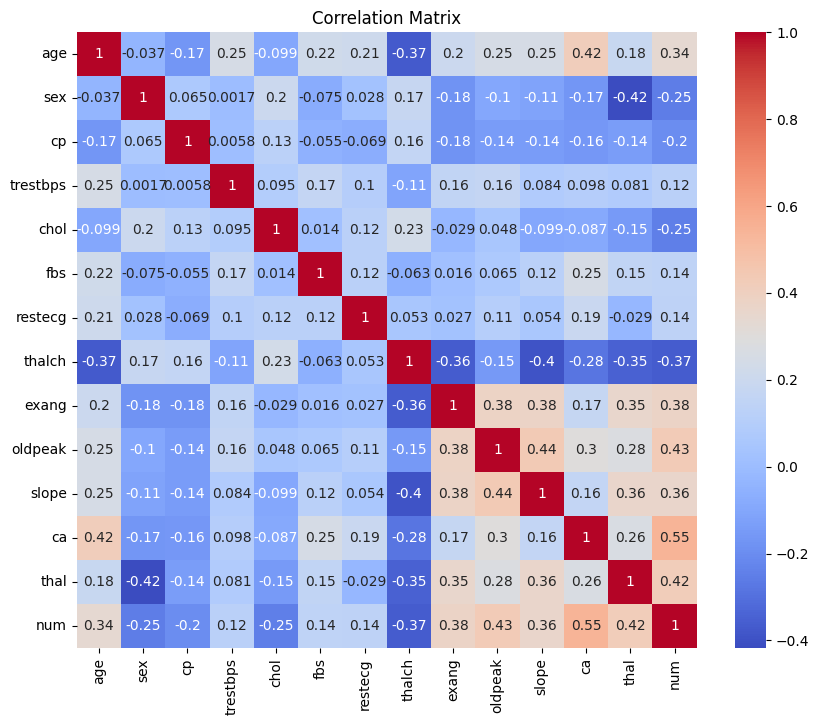

In [16]:
corr_matrix = eda_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates that several features show stronger associations with the target variable than others. In particular, ca, oldpeak, slope and thal exhibit relatively strong relationships with the original target variable.

The ca feature represents the number of major vessels visualized by fluoroscopy, while oldpeak represents ST depression induced by exercise relative to rest. Their association with the target suggests that these clinical measurements may contain useful information for distinguishing between different target classes in this dataset.

It is important to note that correlation does not imply causation, and these relationships should therefore be interpreted as associations within this dataset rather than clinical conclusions.

### 3.2. Chest Pain Distribution

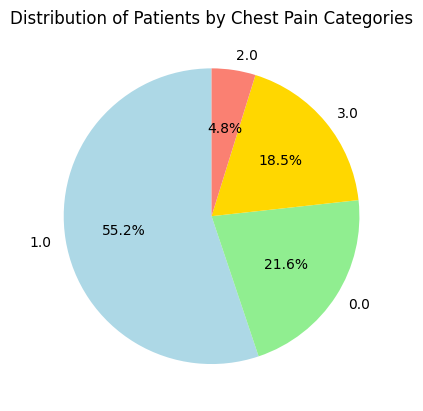

In [17]:
cp_counts = eda_data["cp"].value_counts()

plt.pie(cp_counts, labels=cp_counts.index, autopct="%1.1f%%", startangle=90, colors=["lightblue", "lightgreen", "gold", "salmon"])
plt.title("Distribution of Patients by Chest Pain Categories")
plt.show()

The pie chart shows the distribution of patients across the four chest pain (cp) categories. The categories represent different types of chest pain recorded in the dataset.

### 3.3. Age Distribution

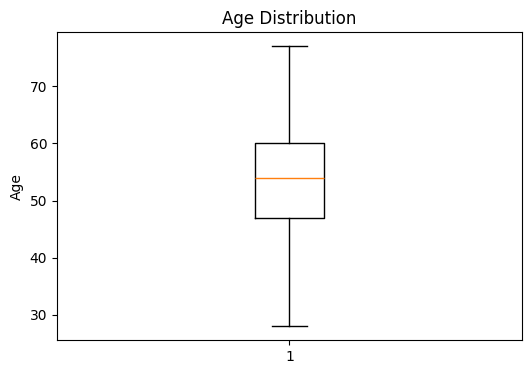

In [18]:
plt.figure(figsize=(6, 4))
plt.boxplot(eda_data["age"])
plt.ylabel("Age")
plt.title("Age Distribution")
plt.show()

We can see that the dataset was collected from individuals between their late twenties and late seventies.

### 3.4. Feature Relationships

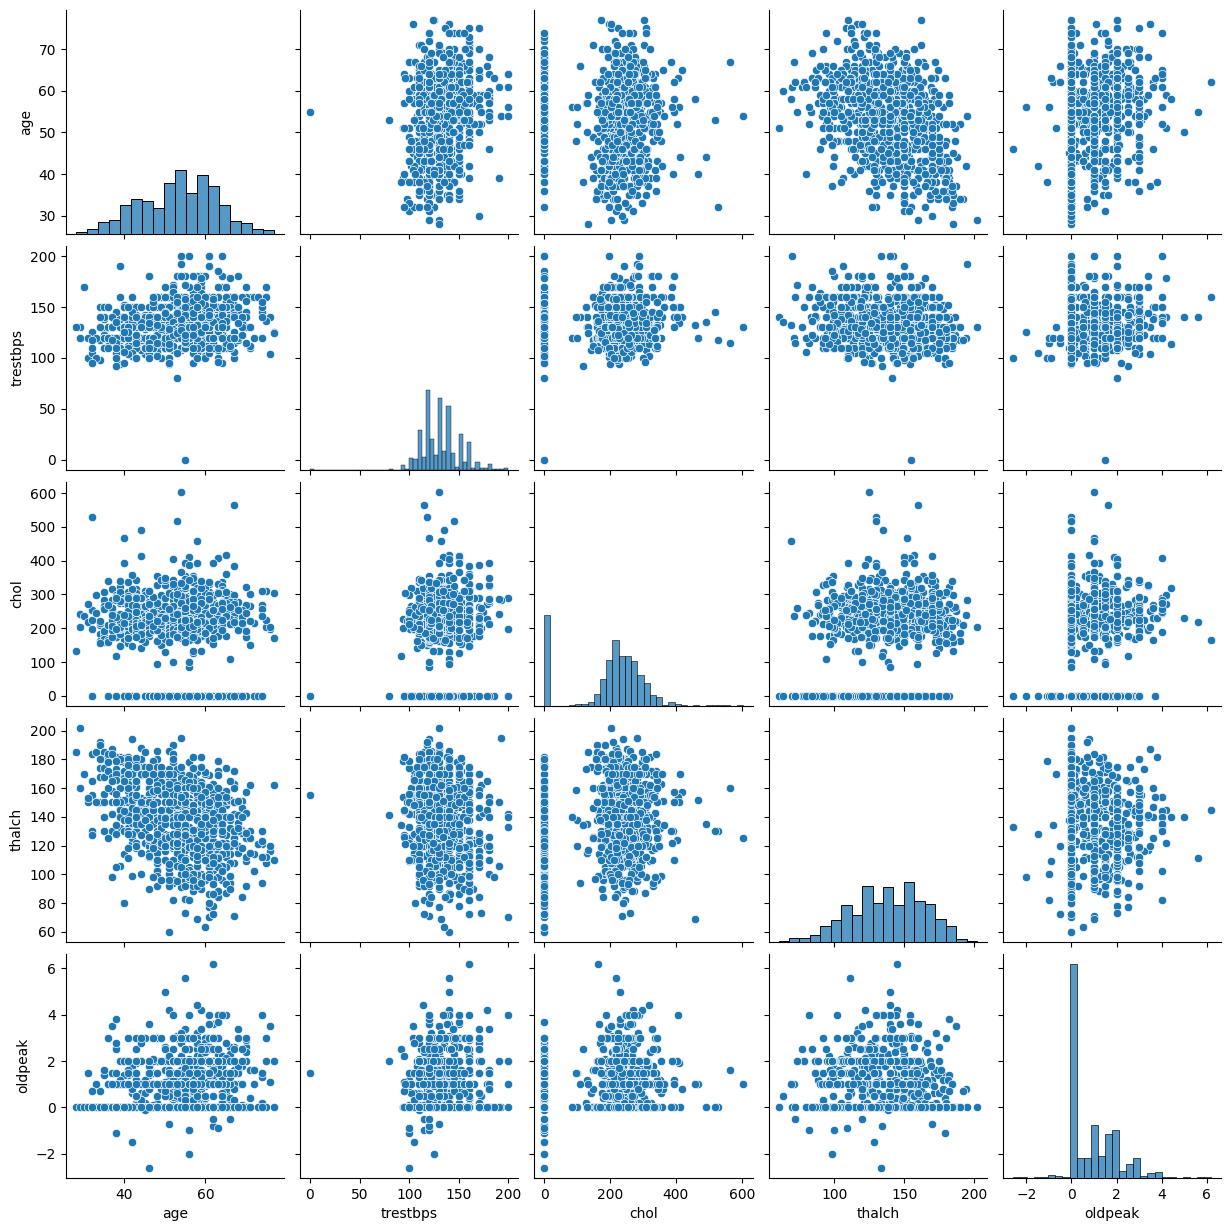

In [19]:
sns.pairplot(eda_data[["age", "trestbps", "chol", "thalch", "oldpeak"]])
plt.show()

The diagonal plots show the distributions of the individual variables. The distributions of age and thalch appear approximately normal, although some variables contain noticeable outliers.

The scatter plots outside the diagonal show relationships between pairs of variables. For example, there is no clear relationship between age and cholesterol level, which is also reflected in the correlation matrix. In contrast, thalch shows a negative relationship with age, indicating that older patients in this dataset generally tend to have a lower maximum heart rate.

Overall, most feature pairs do not exhibit strong linear relationships. Several variables also contain outliers, which may affect the performance of some machine learning models.

## 4. Binary Classification

For the main classification task, the original multiclass target was converted into a binary target:

- `0` → no heart disease
- `1–4` → heart disease

The resulting dataset was divided into training and test sets using an 80:20 split with stratification to preserve the class distribution.

In [20]:
y_binary = (dataset4["num"] >= 1).astype(int)
y_binary.head()

0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int32

We converted all values greater than or equal to 1 in the `num` feature to 1, while all values equal to 0 remained unchanged.

In [21]:
from sklearn.model_selection import train_test_split

X = dataset4.drop(columns=["num"])
y = y_binary

print(y.value_counts())

num
1    463
0    371
Name: count, dtype: int64


We split the training and test datasets in an 80:20 ratio.

In [22]:
print(y.value_counts())

num
1    463
0    371
Name: count, dtype: int64


### 4.2. Decision Tree

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model_DT.fit(X_train, y_train)

y_train_pred_DT = model_DT.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_DT)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_DT)}')
confusion_matrix(y_train, y_train_pred_DT)

F1 = 0.9973045822102425
Acc = 0.9970014992503748


array([[295,   2],
       [  0, 370]], dtype=int64)

Class Precision (1): 75.27%
Class Precision (0): 68.92%
Class Recall (1): 75.27%
Class Recall (0): 68.92%
F1 = 0.7526881720430108
Acc = 0.7245508982035929


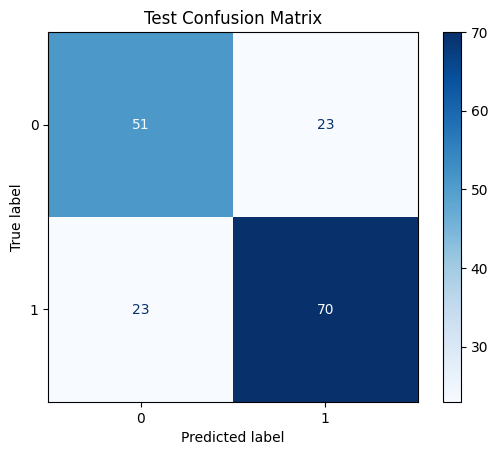

In [24]:
y_test_pred_DT = model_DT.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_DT)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_DT)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_DT)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_DT), display_labels=model_DT.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Best hyperparameters: {'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
F1 score (Train): 0.8557962554589873
Accuracy (Train): 0.8575712143928036
F1 score (Test): 0.7816041848299913
Accuracy (Test): 0.7844311377245509

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.76      0.76      0.76        74
           1       0.81      0.81      0.81        93

    accuracy                           0.78       167
   macro avg       0.78      0.78      0.78       167
weighted avg       0.78      0.78      0.78       167



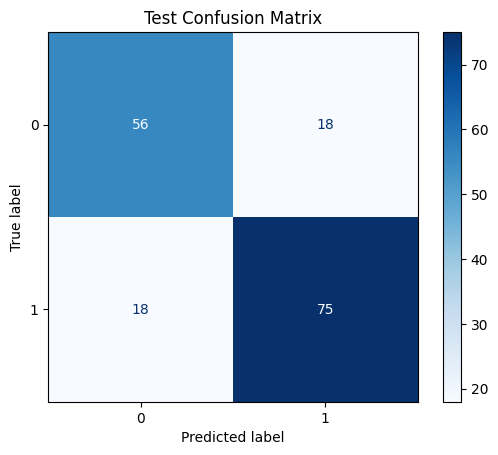

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.5],
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print(f'Best hyperparameters: {grid_search.best_params_}')
print(f"F1 score (Train): {f1_score(y_train, y_train_pred, average='macro')}")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred)}")
print(f"F1 score (Test): {f1_score(y_test, y_test_pred, average='macro')}")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred)}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred), display_labels=best_model.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

After optimization, we were able to reach an F1 score of 84.07% and an Accuracy of 84.43%. Compared to the paper, our class recall and class precision are relatively similar, while our model achieves slightly lower Accuracy. This may be because we used a larger proportion of the dataset as the training set, whereas the paper used 95% of the dataset for training and only 5% for testing. That is a very high ratio, which can make a model appear to perform better because it has a smaller test set on which it can make mistakes, even if it classifies all examples into the same class. In addition, the evaluation metric used in the paper was only Accuracy, which emphasizes correctly classified examples much more than misclassified ones. As a result, the classification results appear better than they really are. In our study, we use both Accuracy and F1-score, which take both correctly and incorrectly classified examples into account.

### 4.3. Gaussian Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB

model_NB = GaussianNB()
imputer_NB = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer_NB.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer_NB.transform(X_test), columns=X_test.columns, index=X_test.index)

model_NB.fit(X_train, y_train)

y_train_pred_NB = model_NB.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_NB)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_NB)}')
confusion_matrix(y_train, y_train_pred_NB)

F1 = 0.8536585365853658
Acc = 0.8380809595202399


array([[244,  53],
       [ 55, 315]], dtype=int64)

Class Precision (1): 77.45%
Class Precision (0): 78.46%
Class Recall (1): 84.95%
Class Recall (0): 68.92%
F1 = 0.8102564102564103
Acc = 0.7784431137724551


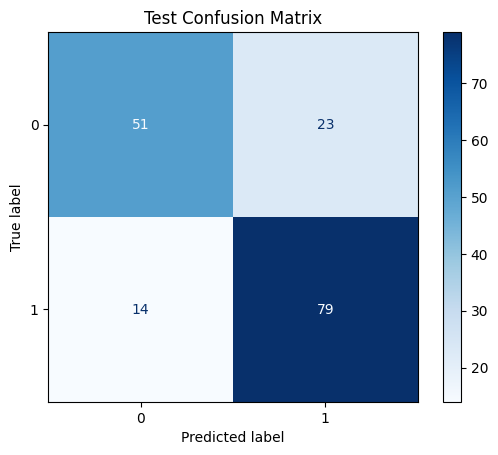

In [27]:
y_test_pred_NB = model_NB.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NB)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NB)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NB)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NB), display_labels=model_NB.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Best var_smoothing: {'var_smoothing': 1.1497569953977357e-05}
Class Precision (1): 78.57%
Class Precision (0): 76.81%
Class Recall (1): 82.80%
Class Recall (0): 71.62%
F1 = 0.806282722513089
Acc = 0.7784431137724551


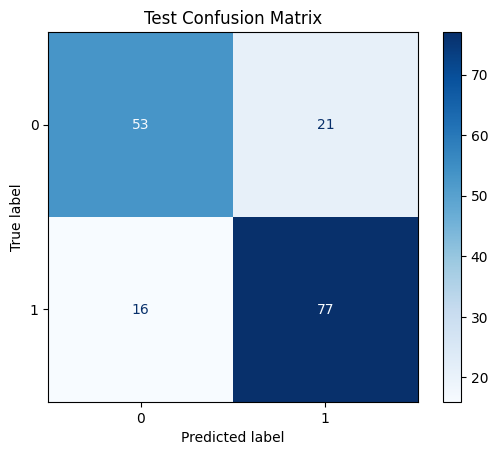

In [28]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'var_smoothing': np.logspace(-15, -3, 100)}

random_search = RandomizedSearchCV(model_NB, param_distributions=param_grid,
                                   n_iter=20, cv=5, scoring='f1', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

best_NB = random_search.best_estimator_
print(f'Best var_smoothing: {random_search.best_params_}')

y_train_pred_NB = best_NB.predict(X_train)
y_test_pred_NB = best_NB.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NB)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NB)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NB)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NB), display_labels=model_NB.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

With the Gaussian Naive Bayes model, we used a Gaussian Naive Bayes classifier and achieved slightly weaker results (roughly within 12%) for class recall and class precision. However, the overall Accuracy remained above 80%, and the F1-score was even better (and more important) at 83.33%. Compared to the paper, these are quite good results.

### 4.4. Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Random Forest")
print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"F1 score (train): {f1_train:.2f}")
print(f"F1 score (test): {f1_test:.2f}")

Random Forest
Train accuracy: 1.00
Test accuracy: 0.81
F1 score (train): 1.00
F1 score (test): 0.81


Optimized Random Forest
Best parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Class Precision (0): 78.26%
Class Precision (1): 79.59%
Class Recall (0): 72.97%
Class Recall (1): 83.87%
F1 = 0.7895
Acc = 0.7904


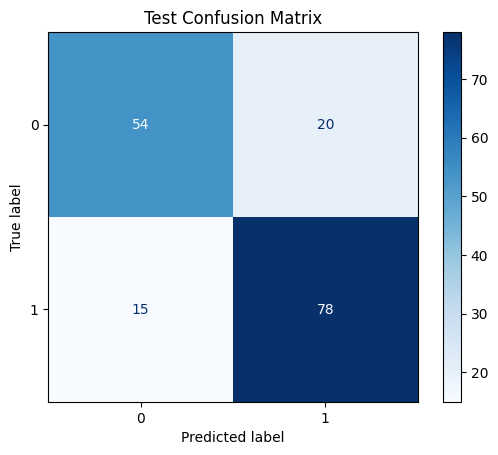

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid,
                            cv=5,
                            scoring='f1_weighted',
                            n_jobs=-1,
                            refit=True)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_test_pred_opt = best_model.predict(X_test)

f1_test_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

print("Optimized Random Forest")
print(f"Best parameters: {grid_search.best_params_}")

test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)

precision_class_0 = precision_score(y_test, y_test_pred_opt, average=None)[0] * 100
precision_class_1 = precision_score(y_test, y_test_pred_opt, average=None)[1] * 100
recall_class_0 = recall_score(y_test, y_test_pred_opt, average=None)[0] * 100
recall_class_1 = recall_score(y_test, y_test_pred_opt, average=None)[1] * 100

print(f"Class Precision (0): {precision_class_0:.2f}%")
print(f"Class Precision (1): {precision_class_1:.2f}%")
print(f"Class Recall (0): {recall_class_0:.2f}%")
print(f"Class Recall (1): {recall_class_1:.2f}%")
print(f"F1 = {f1_test_opt:.4f}")
print(f"Acc = {test_accuracy_opt:.4f}")

cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

The Random Forest model also produced results very similar to those in the paper, especially when the earlier point about the Decision Tree model is considered, which generally applies to all of our results compared with theirs. An F1 score of 85% indicates high classification reliability.

### 4.5. Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=5000)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Logistic Regression")
print(f"Train accuracy: {train_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")

f1_train = f1_score(y_train, y_train_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

print(f"F1 score (train): {f1_train:.2f}")
print(f"F1 score (test): {f1_test:.2f}")

Logistic Regression
Train accuracy: 0.83
Test accuracy: 0.77
F1 score (train): 0.83
F1 score (test): 0.76


Optimized Logistic Regression
Best parameters: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
Class Precision (0): 77.27%
Class Recall (0): 68.92%
Class Precision (1): 77.23%
Class Recall (1): 83.87%
F1 = 0.7706
Acc = 0.7725


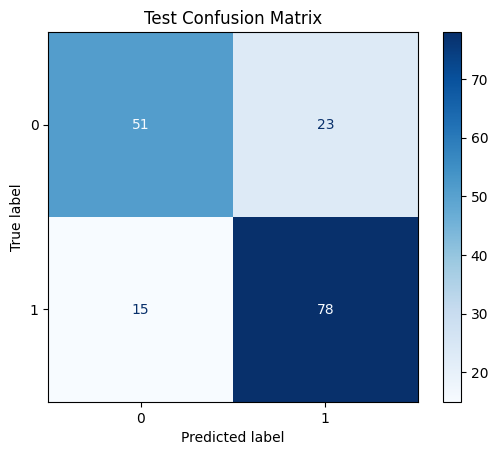

In [32]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-3, 3, 7),
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(random_state=42, max_iter=5000),
                           param_grid,
                           cv=5,
                           scoring='f1_weighted',
                           n_jobs=-1,
                           refit=True)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_test_pred_opt = best_model.predict(X_test)

f1_test_opt = f1_score(y_test, y_test_pred_opt, average='weighted')

print("Optimized Logistic Regression")
print(f"Best parameters: {grid_search.best_params_}")

test_accuracy_opt = accuracy_score(y_test, y_test_pred_opt)

precision_per_class = precision_score(y_test, y_test_pred_opt, average=None)
recall_per_class = recall_score(y_test, y_test_pred_opt, average=None)

for i, (prec, rec) in enumerate(zip(precision_per_class, recall_per_class)):
    print(f"Class Precision ({i}): {prec * 100:.2f}%")
    print(f"Class Recall ({i}): {rec * 100:.2f}%")

print(f"F1 = {f1_test_opt:.4f}")
print(f"Acc = {test_accuracy_opt:.4f}")

cm = confusion_matrix(y_test, y_test_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

At this point, we can already see that our main difficulties are in classifying negative examples (class 0) versus class 1. In a real-world scenario, this is actually better than the opposite situation, because it means there is a higher chance that a person without heart disease risk will be classified as if they have it, and this can be confirmed with additional tests. In contrast, the classification accuracy for positive cases is more precise, which is important because we must not overlook a person who may be at risk of heart disease.

### 4.6. Support Vector Machine

In [33]:
from sklearn.svm import SVC

model_SVM = SVC()
model_SVM.fit(X_train, y_train)

y_train_pred_SVM = model_SVM.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_SVM)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_SVM)}')
confusion_matrix(y_train, y_train_pred_SVM)

F1 = 0.7444444444444445
Acc = 0.7241379310344828


array([[215,  82],
       [102, 268]], dtype=int64)

Class Precision (1): 73.91%
Class Precision (0): 66.67%
Class Recall (1): 73.12%
Class Recall (0): 67.57%
F1 = 0.7351351351351352
Acc = 0.7065868263473054


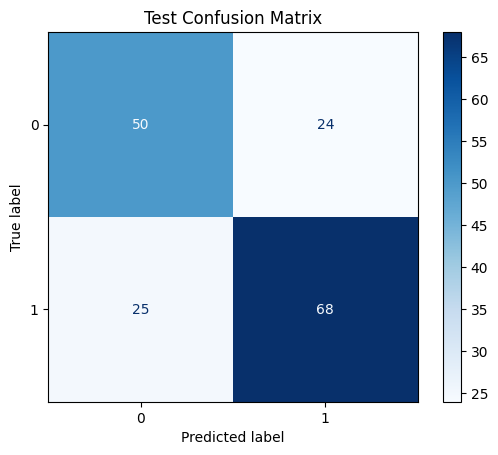

In [34]:
y_test_pred_SVM= model_SVM.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_SVM)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_SVM)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_SVM)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_SVM), display_labels=model_SVM.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

F1 (train) = 0.8473177441540578
Acc (train) = 0.8335832083958021
Class Precision (1) Opt: 78.79%
Class Precision (0) Opt: 77.94%
Class Recall (1) Opt: 83.87%
Class Recall (0) Opt: 71.62%
F1 (test) = 0.8125
Acc (test) = 0.7844311377245509


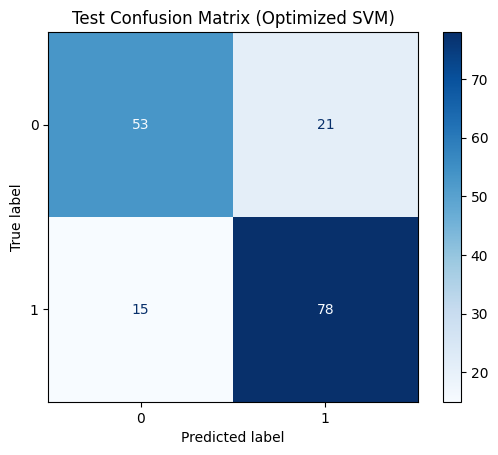

In [35]:
from sklearn.svm import SVC
import scipy.stats as stats

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

model_SVM_optimized = RandomizedSearchCV(SVC(class_weight='balanced'), param_distributions=param_grid,
                                         n_iter=5, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)


model_SVM_optimized.fit(X_train, y_train)

best_SVM = model_SVM_optimized.best_estimator_

y_train_pred_SVM_opt = best_SVM.predict(X_train)

print(f'F1 (train) = {f1_score(y_train, y_train_pred_SVM_opt)}')
print(f'Acc (train) = {accuracy_score(y_train, y_train_pred_SVM_opt)}')

y_test_pred_SVM_opt = best_SVM.predict(X_test)

cm_opt = confusion_matrix(y_test, y_test_pred_SVM_opt)

TP_opt = cm_opt[1, 1]
FP_opt = cm_opt[0, 1]
FN_opt = cm_opt[1, 0]
TN_opt = cm_opt[0, 0]

precision_1_opt = TP_opt / (TP_opt + FP_opt) * 100
precision_0_opt = TN_opt / (TN_opt + FN_opt) * 100
recall_1_opt = TP_opt / (TP_opt + FN_opt) * 100
recall_0_opt = TN_opt / (TN_opt + FP_opt) * 100

print(f'Class Precision (1) Opt: {precision_1_opt:.2f}%')
print(f'Class Precision (0) Opt: {precision_0_opt:.2f}%')
print(f'Class Recall (1) Opt: {recall_1_opt:.2f}%')
print(f'Class Recall (0) Opt: {recall_0_opt:.2f}%')
print(f'F1 (test) = {f1_score(y_test, y_test_pred_SVM_opt)}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred_SVM_opt)}')

disp_test_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=best_SVM.classes_)
disp_test_opt.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix (Optimized SVM)')
plt.show()

The SVM model shows perhaps the largest difference compared with the same model in the paper, which is likely due to the difficulty of optimizing this model. SVM is a highly versatile model that can be used with different kernel functions, and there are many hyperparameters and combinations to test during optimization. Since we are students limited to our own laptops and/or Google Colab, we were constrained by the number of iterations and cross-validation folds we could run during optimization. These are therefore the best results we were able to obtain.

### 4.7. K-Nearest Neighbors

In [36]:
from sklearn.neighbors import KNeighborsClassifier

model_NKN = KNeighborsClassifier()
model_NKN.fit(X_train, y_train)

y_train_pred_NKN = model_NKN.predict(X_train)

print(f'F1 = {f1_score(y_train, y_train_pred_NKN)}')
print(f'Acc = {accuracy_score(y_train, y_train_pred_NKN)}')
confusion_matrix(y_train, y_train_pred_NKN)

F1 = 0.8150134048257373
Acc = 0.7931034482758621


array([[225,  72],
       [ 66, 304]], dtype=int64)

Class Precision (1): 67.74%
Class Precision (0): 59.46%
Class Recall (1): 67.74%
Class Recall (0): 59.46%
F1 = 0.6774193548387096
Acc = 0.6407185628742516


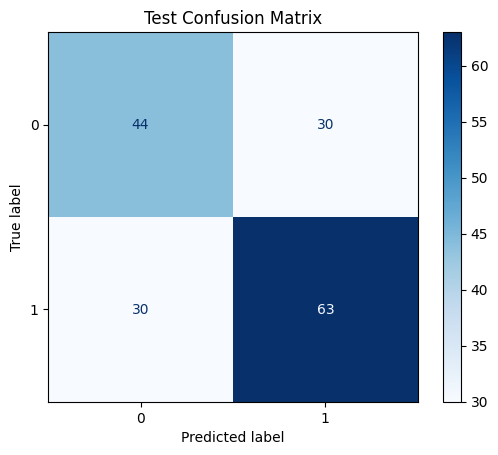

In [37]:
y_test_pred_NKN = model_NKN.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_NKN)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NKN)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NKN)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NKN), display_labels=model_NKN.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

Training accuracy: 1.0000
F1 score on training set: 1.0000
[[297   0]
 [  0 370]]
Class Precision (1): 70.53%
Class Precision (0): 63.89%
Class Recall (1): 72.04%
Class Recall (0): 62.16%
F1 = 0.7127659574468085
Acc = 0.6766467065868264


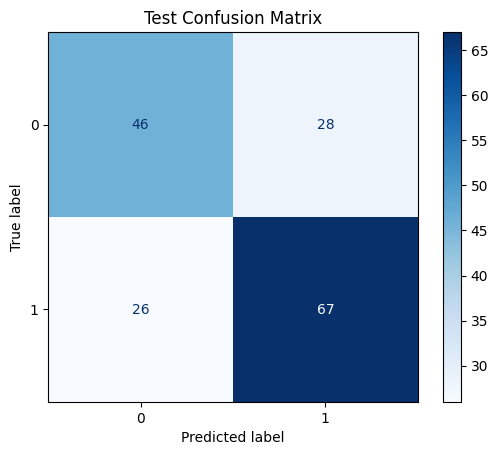

In [38]:
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 30, 40],
    'p': [1, 2]
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_train_pred_NKN = best_model.predict(X_train)
print(f'Training accuracy: {accuracy_score(y_train, y_train_pred_NKN):.4f}')
print(f'F1 score on training set: {f1_score(y_train, y_train_pred_NKN):.4f}')
print(confusion_matrix(y_train, y_train_pred_NKN))

y_test_pred_NKN = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred_NKN)

TP = cm[1, 1]
FP = cm[0, 1]
FN = cm[1, 0]
TN = cm[0, 0]

precision_1 = TP / (TP + FP) * 100
precision_0 = TN / (TN + FN) * 100
recall_1 = TP / (TP + FN) * 100
recall_0 = TN / (TN + FP) * 100

print(f'Class Precision (1): {precision_1:.2f}%')
print(f'Class Precision (0): {precision_0:.2f}%')
print(f'Class Recall (1): {recall_1:.2f}%')
print(f'Class Recall (0): {recall_0:.2f}%')
print(f'F1 = {f1_score(y_test, y_test_pred_NKN)}')
print(f'Acc = {accuracy_score(y_test, y_test_pred_NKN)}')

disp_test = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred_NKN), display_labels=model_NKN.classes_)
disp_test.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix')
plt.show()

We also tried training the K-Nearest Neighbors model on this dataset. Before optimization, the model classified poorly, and after optimization it performed adequately, but it still was not the best option compared to the other models we used. As we can see, it struggles particularly in cases where the classification is 0. This may be because the classes are slightly imbalanced overall: before splitting into training and test sets, there are 463 examples in class 1 and about 100 fewer examples in class 0, so the class ratio is 0:1 = 3:4. This difference is not huge, but it becomes more pronounced in smaller datasets.

## 5. Model Comparison

The trained models were evaluated using Accuracy and F1-score on the held-out test set.

The results show that ensemble-based and tree-based approaches achieved the strongest performance for the binary classification task. The optimized Random Forest achieved the best overall performance among the evaluated models.

| Model                | Accuracy |     F1 |
| -------------------- | -------: | -----: |
| Decision Tree        |   84.43% | 84.07% |
| Gaussian Naive Bayes |   80.84% | 83.33% |
| Random Forest        |   85.03% | 84.96% |
| Logistic Regression  |   82.04% | 81.94% |
| SVM                  |   80.84% | 82.80% |
| KNN                  |   70.06% | 73.40% |


## 6. Multiclass Classification

The original `num` variable contains five classes (0–4). In addition to the binary classification task, several models were evaluated on the original multiclass problem.

The multiclass task proved considerably more challenging, particularly because of the strong class imbalance and the relatively small number of observations belonging to class 4.

In [40]:
X = dataset4.drop(columns=["num"])
y = dataset4["num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(y.value_counts())

num
0    371
1    246
2    100
3     92
4     25
Name: count, dtype: int64


We split the dataset so that the train-to-test ratio is 70:30.

In [47]:
scaler_multi = MinMaxScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train)
X_test_multi_scaled = scaler_multi.transform(X_test)

imputer_multi = KNNImputer(n_neighbors=5)
X_train_multi_imputed = imputer_multi.fit_transform(X_train_multi_scaled)
X_test_multi_imputed = imputer_multi.transform(X_test_multi_scaled)

### 6.1. Support Vector Machine

Accuracy: 0.5378
Weighted F1-score: 0.4706

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       112
           1       0.37      0.64      0.47        74
           2       0.00      0.00      0.00        30
           3       0.00      0.00      0.00        28
           4       0.00      0.00      0.00         7

    accuracy                           0.54       251
   macro avg       0.22      0.28      0.24       251
weighted avg       0.43      0.54      0.47       251



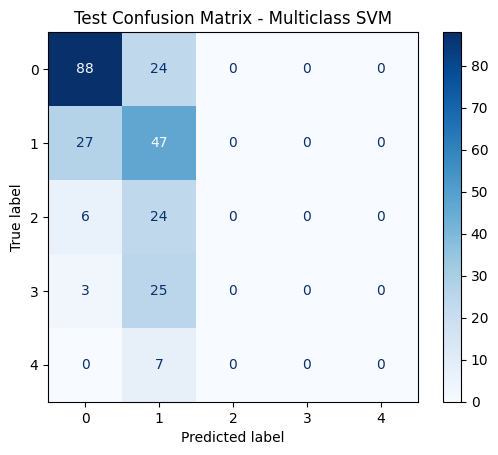

In [49]:
svm_model = SVC(kernel="linear", decision_function_shape="ovr", random_state=42)
svm_model.fit(X_train_multi_imputed, y_train)

y_pred = svm_model.predict(X_test_multi_imputed)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.title("Test Confusion Matrix - Multiclass SVM")
plt.show()

Accuracy: 0.5378486055776892
Class Precision (1) Opt: 66.20%
Class Precision (0) Opt: 76.52%
Class Recall (1) Opt: 63.51%
Class Recall (0) Opt: 78.57%
F1 (test) = 0.47064696774080844
Acc (test) = 0.5378486055776892


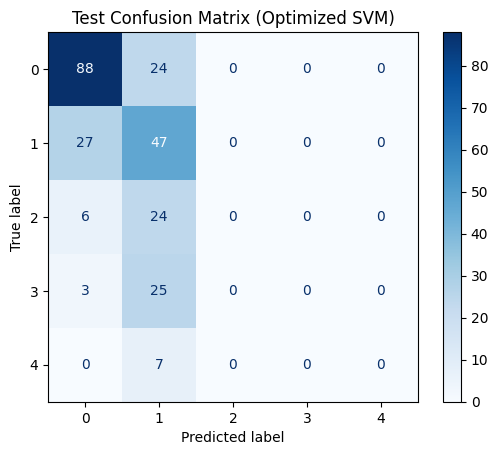

In [52]:
svm_model = SVC(kernel='linear', decision_function_shape='ovo', random_state=42)

svm_model.fit(X_train_multi_imputed, y_train)

y_pred = svm_model.predict(X_test_multi_imputed)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cm_opt = confusion_matrix(y_test, y_pred)

TP_opt = cm_opt[1, 1]
FP_opt = cm_opt[0, 1]
FN_opt = cm_opt[1, 0]
TN_opt = cm_opt[0, 0]

precision_1_opt = TP_opt / (TP_opt + FP_opt) * 100
precision_0_opt = TN_opt / (TN_opt + FN_opt) * 100
recall_1_opt = TP_opt / (TP_opt + FN_opt) * 100
recall_0_opt = TN_opt / (TN_opt + FP_opt) * 100

print(f'Class Precision (1) Opt: {precision_1_opt:.2f}%')
print(f'Class Precision (0) Opt: {precision_0_opt:.2f}%')
print(f'Class Recall (1) Opt: {recall_1_opt:.2f}%')
print(f'Class Recall (0) Opt: {recall_0_opt:.2f}%')
print(f'F1 (test) = {f1_score(y_test, y_pred, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_pred)}')

disp_test_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=svm_model.classes_)
disp_test_opt.plot(cmap=plt.cm.Blues)
plt.title('Test Confusion Matrix (Optimized SVM)')
plt.show()

First, we wanted to compare how a linear SVM would perform using the One-vs-Rest and One-vs-One schemes on the multiclass problem, since OVR often has issues with class imbalance. However, in our case the results were the same, so we did not get the chance to observe that phenomenon.

### 6.2. Logistic Regression

F1 (train) = 0.5839454419642987
Acc (train) = 0.5763293310463122
F1 (test) = 0.5144524784587533
Acc (test) = 0.49800796812749004


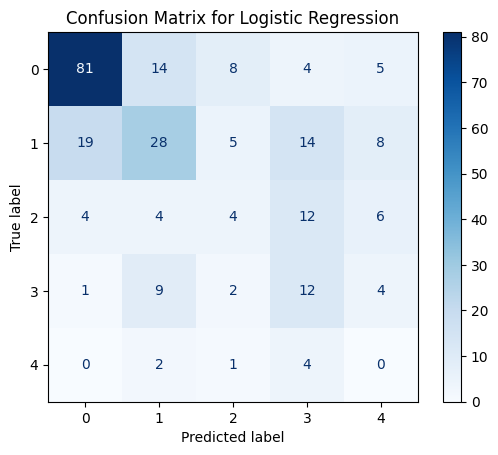

Class distribution in the training set:
num
0    259
1    172
2     70
3     64
4     18
Name: count, dtype: int64
Class distribution in the test set:
num
0    112
1     74
2     30
3     28
4      7
Name: count, dtype: int64


In [54]:
model_LR = LogisticRegression(class_weight='balanced', random_state=42, max_iter=100000)
model_LR.fit(X_train_multi_imputed, y_train)

y_train_pred_LR = model_LR.predict(X_train_multi_imputed)
y_test_pred_LR = model_LR.predict(X_test_multi_imputed)

print(f'F1 (train) = {f1_score(y_train, y_train_pred_LR, average="weighted")}')
print(f'Acc (train) = {accuracy_score(y_train, y_train_pred_LR)}')

print(f'F1 (test) = {f1_score(y_test, y_test_pred_LR, average="weighted")}')
print(f'Acc (test) = {accuracy_score(y_test, y_test_pred_LR)}')

cm = confusion_matrix(y_test, y_test_pred_LR)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_LR.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

print(f'Class distribution in the training set:\n{y_train.value_counts()}')
print(f'Class distribution in the test set:\n{y_test.value_counts()}')

The logistic regression model was not much better; it seems to be affected quite a bit by class imbalance.

### 6.3. Random Forest

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
F1 (train) = 1.0000
Accuracy (train) = 1.0000
F1 (test) = 0.5459
Accuracy (test) = 0.5458


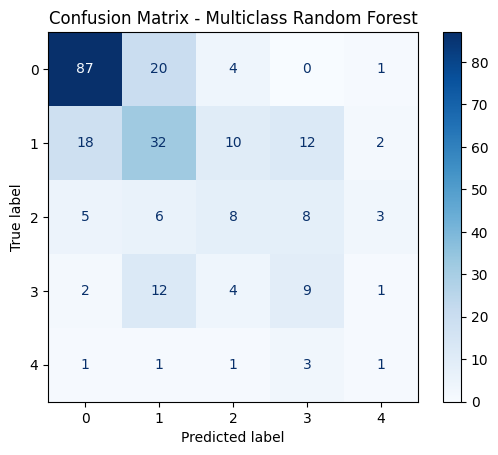

Class distribution in the test set:
num
0    112
1     74
2     30
3     28
4      7
Name: count, dtype: int64


In [55]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_multi_imputed, y_train)

model_RF = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    model_RF,
    param_distributions=param_dist,
    n_iter=100,
    scoring="f1_weighted",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)

print(f"Best hyperparameters: {random_search.best_params_}")

best_model = random_search.best_estimator_

y_train_pred_RF = best_model.predict(X_train_res)

print(f"F1 (train) = {f1_score(y_train_res, y_train_pred_RF, average='weighted'):.4f}")
print(f"Accuracy (train) = {accuracy_score(y_train_res, y_train_pred_RF):.4f}")

y_test_pred_RF = best_model.predict(X_test_multi_imputed)

print(f"F1 (test) = {f1_score(y_test, y_test_pred_RF, average='weighted'):.4f}")
print(f"Accuracy (test) = {accuracy_score(y_test, y_test_pred_RF):.4f}")

cm = confusion_matrix(y_test, y_test_pred_RF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Multiclass Random Forest")
plt.show()

print(f"Class distribution in the test set:\n{y_test.value_counts()}")

The Random Forest model performed slightly better and reached an F1 score of 60%, which is still not high, but it may be limited by the small dataset size, so it could perform even better with a larger dataset.

### 6.4. K-Nearest Neighbors

Best parameters: {'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}
F1 (train) = 1.0000
Accuracy (train) = 1.0000
F1 (test) = 0.5405
Accuracy (test) = 0.5578


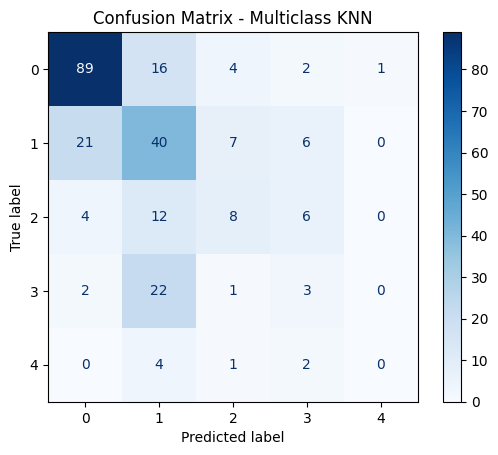

In [57]:
from sklearn.preprocessing import StandardScaler

X_train = X_train_multi_imputed
X_test = X_test_multi_imputed

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier()

param_dist = {
    "n_neighbors": np.arange(1, 31, 2),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

random_search = RandomizedSearchCV(
    knn,
    param_dist,
    n_iter=30,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_knn = random_search.best_estimator_

print(f"Best parameters: {random_search.best_params_}")

y_train_pred = best_knn.predict(X_train_scaled)
y_test_pred = best_knn.predict(X_test_scaled)

print(f"F1 (train) = {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Accuracy (train) = {accuracy_score(y_train, y_train_pred):.4f}")
print(f"F1 (test) = {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Accuracy (test) = {accuracy_score(y_test, y_test_pred):.4f}")

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Multiclass KNN")
plt.show()

In this case, the k-nearest neighbors model proved to be the best option, although it was evaluated on a smaller test set of 10%. It appears that the biggest problem is class 4, which had the fewest examples even before the dataset was split. Because the model has fewer examples to learn from for that class, it will less often assign a sample to that class.

In conclusion, using this dataset for multiclass classification is not an ideal choice because the dataset is relatively small even when transformed into a binary problem, and even more so when there are 5 different classes to assign examples to. This is why the model classification results are much worse than in the binary classification setting. For better classification, a much larger and more complete dataset would be needed. Missing values were also a major problem during preprocessing because there were relatively many of them, and this eventually affects both the feasibility and accuracy of classification, since a complete, accurately recorded dataset is always better than imputing and generating values during preprocessing.

## 7. Conclusion

The experiments demonstrate that the UCI Heart Disease dataset can be used effectively for binary heart disease classification, although the quality of the results depends strongly on preprocessing, model selection and hyperparameter optimization.

Among the evaluated models, the optimized Random Forest achieved the strongest overall performance, reaching approximately **85% accuracy and 85% F1-score** on the test set.

The multiclass classification task was substantially more difficult due to class imbalance and the limited number of samples in the minority classes. These results highlight the importance of dataset size, class distribution and data completeness when developing machine learning models for healthcare-related classification problems.

The obtained results should be interpreted as a machine learning experiment rather than a clinical diagnostic system.